## ELE632 Lab 2
#### Terry Chen 501236148

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, lfiltic, convolve

#### Part A: Unit Impulse Response
* $F = 6$
* $G = 1$
* $H = 4$

**1.I)**
*Substituting the values for $F$ and $G$:*
$$y[n] + \frac{1}{F+1}y[n-1] - \frac{1}{F+1}y[n-2] = \frac{1}{G+1}x[n]$$
$$y[n] + \frac{1}{7}y[n-1] - \frac{1}{7}y[n-2] = \frac{1}{2}x[n]$$

**1.II)**
*Substituting the values for $H$:*
$$y[n] + \frac{1}{H+1}y[n-2] = x[n]$$
$$y[n] + \frac{1}{5}y[n-2] = x[n]$$


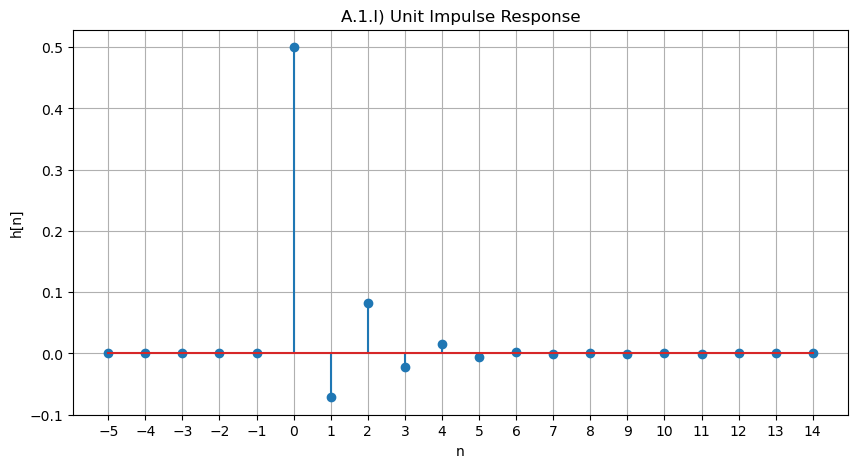

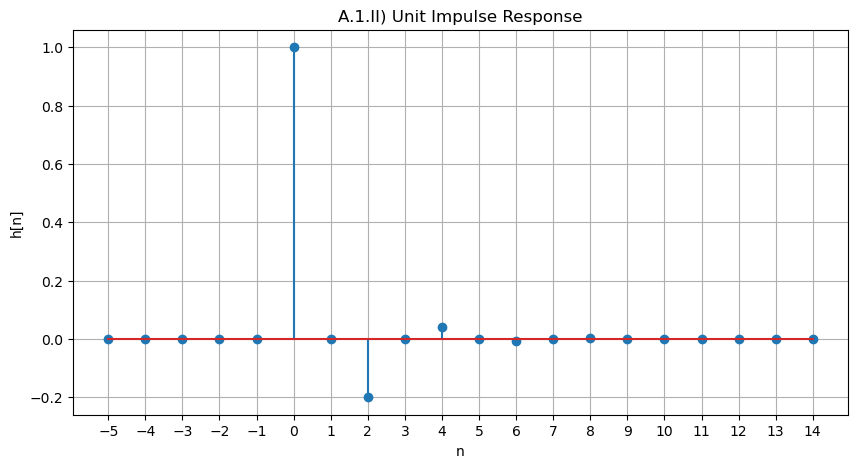

In [63]:
n = np.arange(-5, 15)
d = 1 * (n == 0)

# A.1.I)
xI = [1/2]
yI = [1, 1/7, -1/7]
hI = lfilter(xI, yI, d)

plt.figure(figsize=(10, 5))
plt.stem(n, hI)
plt.xticks(np.arange(min(n), max(n)+1, 1))
plt.title('A.1.I) Unit Impulse Response')
plt.xlabel('n')
plt.ylabel('h[n]')
plt.grid()
plt.show()

# A.1.II)
xII = [1]
yII = [1, 0, 1/5]
hII = lfilter(xII, yII, d)

plt.figure(figsize=(10, 5))
plt.stem(n, hII)
plt.xticks(np.arange(min(n), max(n)+1, 1))
plt.title('A.1.II) Unit Impulse Response')
plt.xlabel('n')
plt.ylabel('h[n]')
plt.grid()
plt.show()

#### Part B: Zero Input Response
* $D = 2$

*Substituting the values for $D$:*
$$y[n] - \frac{2(D+1)}{10}y[n-1] - \frac{1}{10}y[n-2] = 2x[n]$$
$$y[n] - \frac{6}{10}y[n-1] - \frac{1}{10}y[n-2] = 2x[n]$$

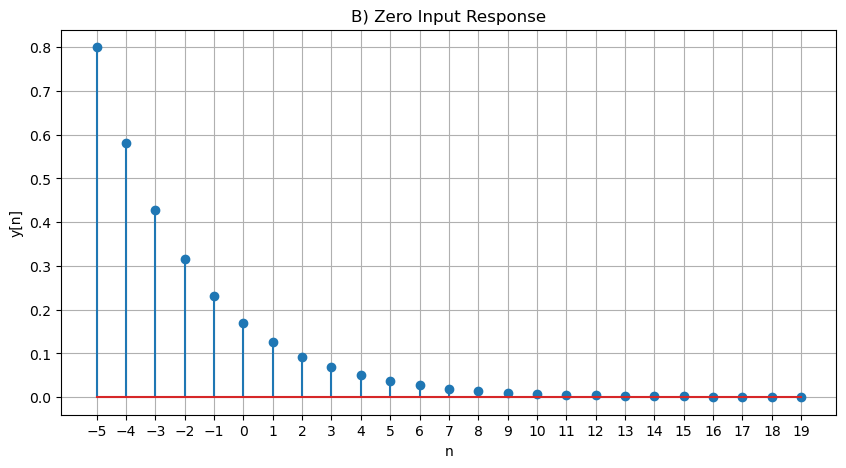

In [80]:
n = np.arange(-5, 20)
x_n = np.zeros(len(n))

x = [2]
y = [1, -6/10, -1/10]

# y[-1] = 1, y[-2] = 2
init_cond = [1, 2]  
zi = lfiltic(x, y, init_cond)
y_zi, _ = lfilter(x, y, x_n, zi=zi)

plt.figure(figsize=(10, 5))
plt.stem(n, y_zi)
plt.xticks(np.arange(min(n), max(n)+1, 1))
plt.title('B) Zero Input Response')
plt.xlabel('n')
plt.ylabel('y[n]')
plt.grid()
plt.show()

#### Part C: Zero State Response
* $D = 2$

*Substituting the values for $D$:*
$$x[n] = 2cos(\frac{2\pi n}{D+1})(u[n]-u[n-(D+1)])$$
$$x[n] = 2cos(\frac{2\pi n}{3})(u[n]-u[n-3])$$

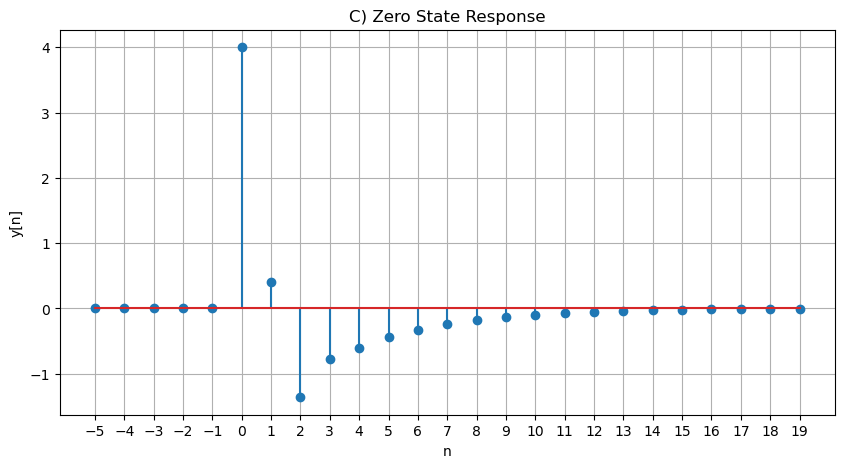

In [62]:
n = np.arange(-5, 20)
x_n = 2 * np.cos(2 * np.pi * n / 3) * (np.mod(n,1)==0) * 1 * (n >= 0) * (n <= 2)

# coefficients from B)
x = [2]
y = [1, -6/10, -1/10]

y_zs = lfilter(x, y, x_n)

plt.figure(figsize=(10, 5))
plt.stem(n, y_zs)
plt.xticks(np.arange(min(n), max(n)+1, 1))
plt.title('C) Zero State Response')
plt.xlabel('n')
plt.ylabel('y[n]')
plt.grid()
plt.show()

#### Part D: Total Response



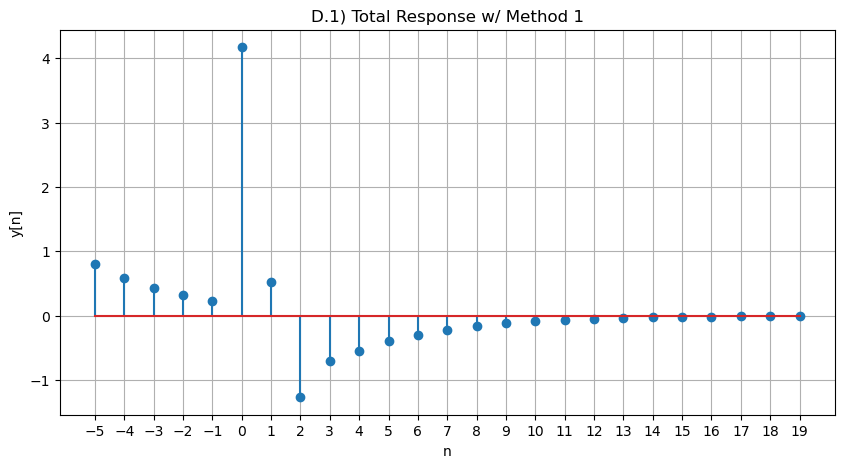

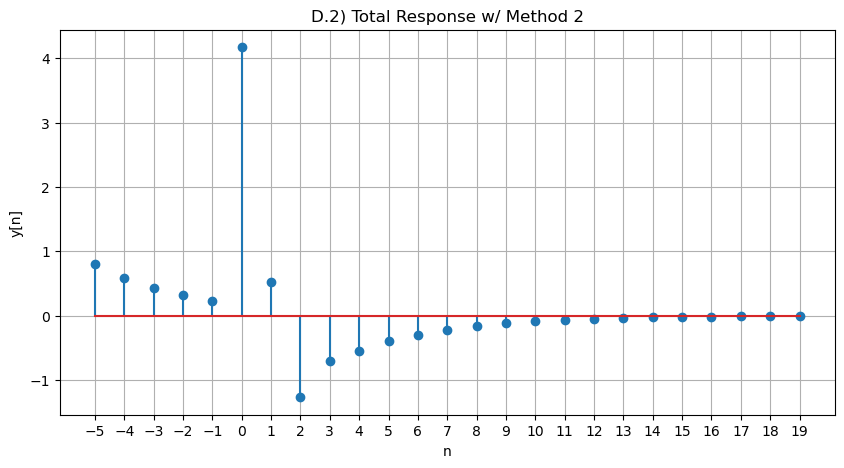

n    | Method 1 | Method 2
n=-5 |  0.8000  |  0.8000
n=-4 |  0.5800  |  0.5800
n=-3 |  0.4280  |  0.4280
n=-2 |  0.3148  |  0.3148
n=-1 |  0.2317  |  0.2317
n= 0 |  4.1705  |  4.1705
n= 1 |  0.5255  |  0.5255
n= 2 | -1.2677  | -1.2677
n= 3 | -0.7081  | -0.7081
n= 4 | -0.5516  | -0.5516
n= 5 | -0.4018  | -0.4018
n= 6 | -0.2962  | -0.2962
n= 7 | -0.2179  | -0.2179
n= 8 | -0.1604  | -0.1604
n= 9 | -0.1180  | -0.1180
n=10 | -0.0868  | -0.0868
n=11 | -0.0639  | -0.0639
n=12 | -0.0470  | -0.0470
n=13 | -0.0346  | -0.0346
n=14 | -0.0255  | -0.0255
n=15 | -0.0187  | -0.0187
n=16 | -0.0138  | -0.0138
n=17 | -0.0101  | -0.0101
n=18 | -0.0075  | -0.0075
n=19 | -0.0055  | -0.0055


In [79]:
n = np.arange(-5, 20)
x = [2]
y = [1, -6/10, -1/10]
init_cond = [1, 2]
x_n = 2 * np.cos(2 * np.pi * n / 3) * (np.mod(n,1)==0) * 1 * (n >= 0) * (n <= 2)

# D.1)
zi = lfiltic(x, y, init_cond)
y_tot, _ = lfilter(x, y, x_n, zi=zi)

plt.figure(figsize=(10, 5))
plt.stem(n, y_tot)
plt.xticks(np.arange(min(n), max(n)+1, 1))
plt.title('D.1) Total Response w/ Method 1')
plt.xlabel('n')
plt.ylabel('y[n]')
plt.grid()
plt.show()

# D.2)
y_tot2 = y_zi + y_zs

plt.figure(figsize=(10, 5))
plt.stem(n, y_tot2)
plt.xticks(np.arange(min(n), max(n)+1, 1))
plt.title('D.2) Total Response w/ Method 2')
plt.xlabel('n')
plt.ylabel('y[n]')
plt.grid()
plt.show()

# comparison of methods
print(f"n    | Method 1 | Method 2")
for i in range(len(n)): 
    print(f"n={n[i]:2} | {y_tot[i]:7.4f}  | {y_tot2[i]:7.4f}")

#### Part E: Convolution and System Stability


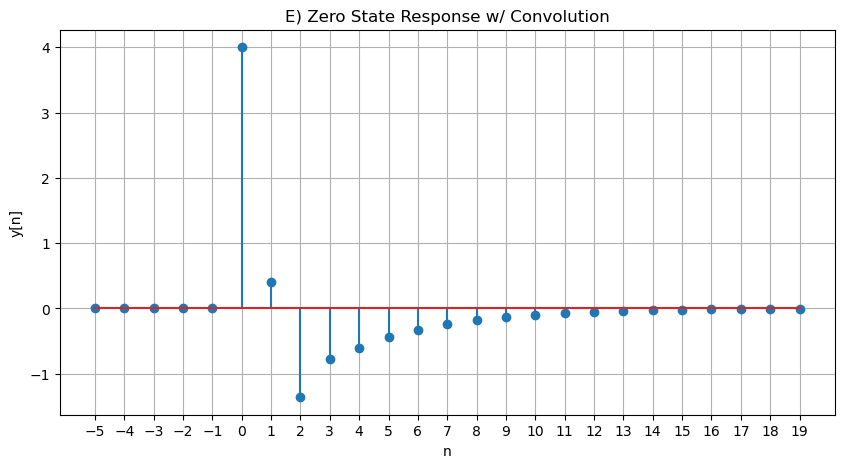

n    |  From C  |  From E
n=-5 |  0.0000  |  0.0000
n=-4 |  0.0000  |  0.0000
n=-3 |  0.0000  |  0.0000
n=-2 |  0.0000  |  0.0000
n=-1 |  0.0000  |  0.0000
n= 0 |  4.0000  |  4.0000
n= 1 |  0.4000  |  0.4000
n= 2 | -1.3600  | -1.3600
n= 3 | -0.7760  | -0.7760
n= 4 | -0.6016  | -0.6016
n= 5 | -0.4386  | -0.4386
n= 6 | -0.3233  | -0.3233
n= 7 | -0.2378  | -0.2378
n= 8 | -0.1750  | -0.1750
n= 9 | -0.1288  | -0.1288
n=10 | -0.0948  | -0.0948
n=11 | -0.0698  | -0.0698
n=12 | -0.0513  | -0.0513
n=13 | -0.0378  | -0.0378
n=14 | -0.0278  | -0.0278
n=15 | -0.0205  | -0.0205
n=16 | -0.0151  | -0.0151
n=17 | -0.0111  | -0.0111
n=18 | -0.0082  | -0.0082
n=19 | -0.0060  | -0.0060

Poles: 0.7359, -0.1359
Magnitudes: 0.7359, 0.1359


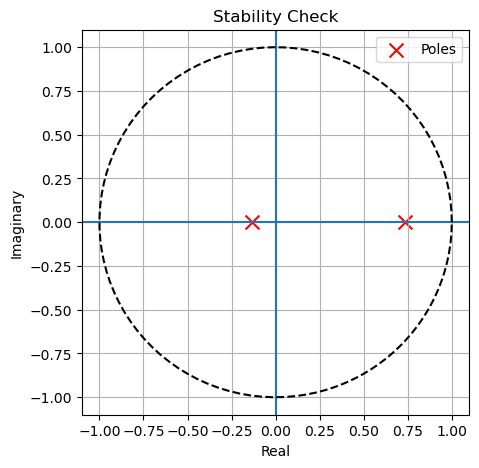

magnitude < 1 for all poles, the limit as n->inf is 0.


In [148]:
n = np.arange(-5, 20)
d = 1 * (n == 0)

x = [2]
y = [1, -6/10, -1/10]
x_n = 2 * np.cos(2 * np.pi * n / 3) * (np.mod(n,1)==0) * 1 * (n >= 0) * (n <= 2)

h_n = lfilter(x, y, d) # unit impulse response
y_conv = convolve(x_n[n >= 0], h_n[n >= 0]) # convolution of the input signal and unit impulse response

y_conv_zs = np.zeros(len(n))
y_conv_zs[n >= 0] = y_conv[:len(n[n >= 0])]

plt.figure(figsize=(10, 5))
plt.stem(n, y_conv_zs)
plt.xticks(np.arange(min(n), max(n)+1, 1))
plt.title('E) Zero State Response w/ Convolution')
plt.xlabel('n')
plt.ylabel('y[n]')
plt.grid()
plt.show()

# comparison of C w/ E
print(f"n    |  From C  |  From E")
for i in range(len(n)): 
    print(f"n={n[i]:2} | {y_zs[i]:7.4f}  | {y_conv_zs[i]:7.4f}")

# asymptotic stability
poles = np.roots(y)
magnitudes = np.abs(poles)
print(f"\nPoles: {poles[0]:.4f}, {poles[1]:.4f}")
print(f"Magnitudes: {magnitudes[0]:.4f}, {magnitudes[1]:.4f}")

plt.figure(figsize=(5, 5))
plt.axhline(0)
plt.axvline(0)

plt.plot(np.cos(theta), np.sin(theta), 'k--')
plt.scatter(poles.real, poles.imag, s=100, marker='x', color='red', label='Poles') # poles

plt.title('Stability Check')
plt.xlabel('Real')
plt.ylabel('Imaginary')
plt.legend()
plt.grid()
plt.show()

print(f"magnitude < 1 for all poles, the limit as n->inf is 0.")


#### Part F: Moving average filter
* $D = 2$
* $G = 1$
* $H = 4$

*Substituting the values for $D$, $G$, and $H$:*
$$x[n] = cos(\frac{\pi n}{D+1}) - \delta[n-(G+1)] + \delta[n-(H+1)]$$
$$x[n] = cos(\frac{\pi n}{3}) - \delta[n-2] + \delta[n-5]$$

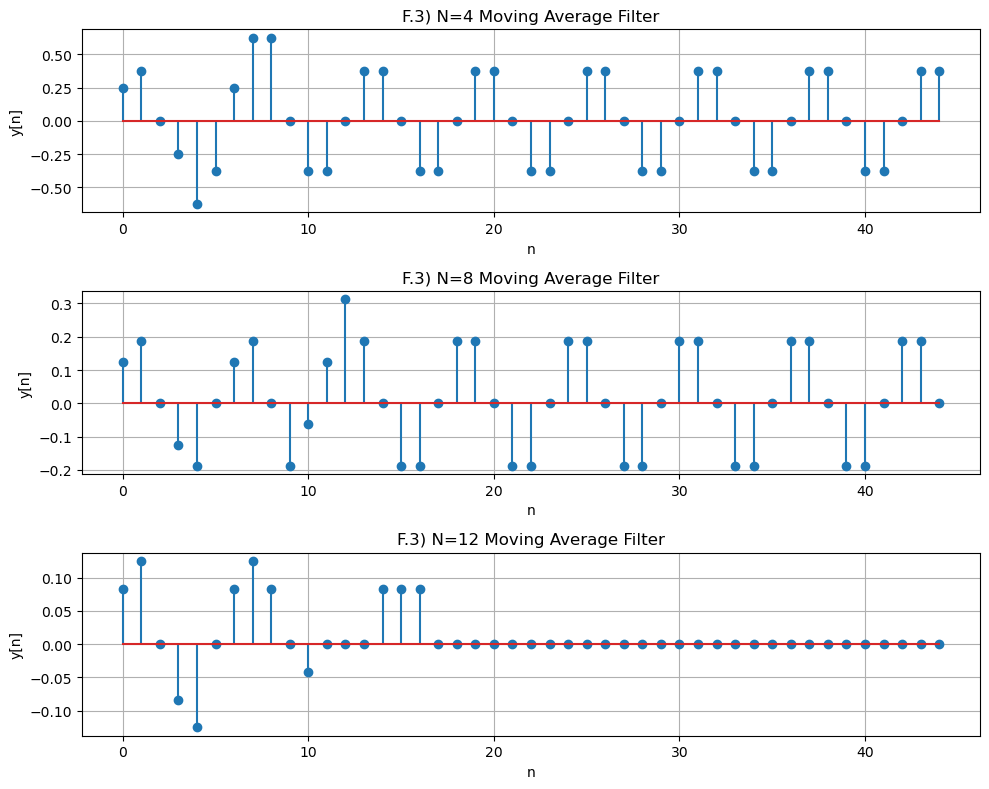

In [178]:
# gets vectors b and a for a causal N-point moving-average filter
def compute_params(N):
    # b is an array of N elements, each being 1/N
    b = np.ones(N) / N
    a = [1]
    
    return b, a

n_f = np.arange(0, 45)
x_f = np.cos(np.pi * n_f / (3)) - (n_f == 2) + (n_f == 5)

N_values = [4, 8, 12]
plt.figure(figsize=(10, 8))

for i, N in enumerate(N_values):
    b, a = compute_params(N)
    y_f = lfilter(b, a, x_f)
    
    plt.subplot(3, 1, i+1)
    plt.stem(n_f, y_f)
    plt.title(f'F.3) N={N} Moving Average Filter')
    plt.xlabel('n')
    plt.ylabel('y[n]')
    plt.grid()

plt.tight_layout()
plt.show()